In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year

DB = pd.read_csv("Data2.csv")
print(DB)


       Patient_ID   Age  Gender       Country  Height_cm  Weight_kg   BMI  \
0               1  32.0    Male     Singapore      163.7      125.8  46.9   
1               2  31.0    Male        Brazil      155.6       60.5  25.0   
2               3  44.0   Other         India      155.0       88.7  36.9   
3               4  36.0  Female        France      167.0       55.4  19.9   
4               5   NaN    Male  South Africa        NaN        NaN  30.8   
...           ...   ...     ...           ...        ...        ...   ...   
49995       49996  67.0   Other        Brazil      153.0      126.5  54.0   
49996       49997  67.0   Other    Bangladesh      183.9      126.4  37.4   
49997       49998  31.0   Other  South Africa      150.4       95.2  42.1   
49998       49999  60.0  Female  Saudi Arabia        NaN       51.4  31.7   
49999       50000  59.0  Female         China      174.9       89.5  29.3   

       Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Blood_Glucose  ..

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Preparar el DataFrame
DB_Alter = DB.copy()
DB_Alter = DB_Alter.drop(columns=['Patient_ID', 'Country', 'AI_Health_Recommendation',
                                'Doctor_Consultation_Needed', 'CKD_Risk_Score', "Work_Type"])
DB_Alter = DB_Alter.dropna()

# 2. Definir las listas de columnas (SIN paréntesis al final)
estandarizar = ["BMI", "Hemoglobin"]
normalizar = ["Age", "Height_cm", "Weight_kg", "Blood_Pressure_Systolic",
              "Blood_Pressure_Diastolic", "Blood_Glucose", "Serum_Creatinine",
              "Blood_Urea", "eGFR", "Albumin", "Sodium", "Potassium",
              "Heart_Rate", "Exercise_Hours_Per_Week", "Daily_Water_Intake_L", "Sleep_Hours"]

# 3. Aplicar StandardScaler a la lista 'estandarizar'
scaler_std = StandardScaler()
DB_Alter[estandarizar] = scaler_std.fit_transform(DB_Alter[estandarizar])

# 4. Aplicar MinMaxScaler a la lista 'normalizar'
scaler_minmax = MinMaxScaler()
DB_Alter[normalizar] = scaler_minmax.fit_transform(DB_Alter[normalizar])
print(DB_Alter)

            Age  Gender  Height_cm  Weight_kg       BMI  \
0      0.194444    Male      0.374   0.950588  1.548397   
1      0.180556    Male      0.212   0.182353 -0.580883   
2      0.361111   Other      0.200   0.514118  0.576123   
3      0.250000  Female      0.440   0.122353 -1.076743   
5      0.138889   Other      0.140   0.802353  1.752575   
...         ...     ...        ...        ...       ...   
49994  0.125000    Male      0.030   0.427059  0.673350   
49995  0.680556   Other      0.160   0.958824  2.238712   
49996  0.680556   Other      0.778   0.957647  0.624737   
49997  0.180556   Other      0.108   0.590588  1.081706   
49999  0.569444  Female      0.598   0.523529 -0.162805   

       Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Blood_Glucose  \
0                     0.144444                      0.86       0.732000   
1                     0.855556                      0.32       0.183333   
2                     0.100000                      0.76       0.5

In [3]:
DB_Alter[estandarizar] = DB_Alter[estandarizar].round(2)
DB_Alter[normalizar] = DB_Alter[normalizar].round(2)

In [4]:
dic_DB_Gender = {
    "Male": 1,
    "Other": 2,
    "Female": 3
}
dic_DB_smoke = {
    "Never": 1,
    "Former": 2,
    "Current":3
}
dic_DB_alcohol = {
    "Never": 1,
    "Occasionally": 2,
    "Frequently":3
}
dic_DB_Activity = {
    "Low": 1,
    "Moderate": 2,
    "High":3
}
dic_DB_salt = {
    "Low": 1,
    "Moderate": 2,
    "High":3
}
dic_DB_stress = {
    "Low": 1,
    "Moderate": 2,
    "High":3
}
dic_DB_Diet = {
    "Healthy": 1,
    "Avarage": 2,
    "Poor":3
}
dic_DB_FamilyCKD = {
    "No": 0,
    "Yes": 1
}
dic_DB_Diabetes = {
    "No": 0,
    "Yes": 1
}
dic_DB_Hypertension = {
    "No": 0,
    "Yes": 1
}
dic_DB_Heart_Disease = {
    "No": 0,
    "Yes": 1
}
dic_DB_Kidney_Stone_History = {
    "No": 0,
    "Yes": 1
}
dic_DB_Medication = {
    "Good": 1,
    "Avarage": 2,
    "Poor":3
}

dic_DB_Residence = {
    "Urban": 1,
    "Rural": 2,
}
dic_DB_Air_Polution = {
    "Low": 1,
    "Medium": 2,
    "High":3
}
dic_DB_CDK_RISK = {
    "Low": 0,
    "Moderate": 1,
    "High":2
}




DB_Alter["Gender"] = DB_Alter["Gender"].map(dic_DB_Gender)
DB_Alter["Smoking_Status"] = DB_Alter["Smoking_Status"].map(dic_DB_smoke)
DB_Alter["Alcohol_Consumption"] = DB_Alter["Alcohol_Consumption"].map(dic_DB_alcohol)
DB_Alter["Physical_Activity_Level"] = DB_Alter["Physical_Activity_Level"].map(dic_DB_Activity)
#
DB_Alter["Daily_Salt_Intake"] = DB_Alter["Daily_Salt_Intake"].map(dic_DB_salt)
DB_Alter["Stress_Level"] = DB_Alter["Stress_Level"].map(dic_DB_stress)
DB_Alter["Diet_Quality"] = DB_Alter["Diet_Quality"].map(dic_DB_Diet)
DB_Alter["Family_History_CKD"] = DB_Alter["Family_History_CKD"].map(dic_DB_FamilyCKD)
#
DB_Alter["Diabetes"] = DB_Alter["Diabetes"].map(dic_DB_Diabetes)
DB_Alter["Hypertension"] = DB_Alter["Hypertension"].map(dic_DB_Hypertension)
DB_Alter["Heart_Disease"] = DB_Alter["Heart_Disease"].map(dic_DB_Heart_Disease)
DB_Alter["Kidney_Stone_History"] = DB_Alter["Kidney_Stone_History"].map(dic_DB_Kidney_Stone_History)
#
DB_Alter["Medication_Adherence"] = DB_Alter["Medication_Adherence"].map(dic_DB_Medication)
DB_Alter["Residence_Type"] = DB_Alter["Residence_Type"].map(dic_DB_Residence)
DB_Alter["Air_Pollution_Exposure"] = DB_Alter["Air_Pollution_Exposure"].map(dic_DB_Air_Polution)
DB_Alter["CKD_Risk"] = DB_Alter["CKD_Risk"].map(dic_DB_CDK_RISK)





In [5]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

# ==========================================
# VARIABLE OBJETIVO
# ==========================================

y = DB_Alter["CKD_Risk"]

# ==========================================
# VARIABLES DE ENTRADA
# ==========================================

x = DB_Alter.drop("CKD_Risk", axis=1)

# ==========================================
# SEPARAR ENTRENAMIENTO Y PRUEBA
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=27,
    stratify=y
)

print("Características de entrada:", x_train.shape[1])
print("CKD_Risk:", y.nunique())

# ==========================================
# CREANDO MODELO
# ==========================================

model = Sequential()

model.add(Dense(
    32,
    input_dim=x_train.shape[1],
    activation="relu"
))

model.add(Dense(
    16,
    activation="relu"
))

# 3 neuronas porque tenemos 3 clases
model.add(Dense(
    3,
    activation="softmax"
))

# ==========================================
# COMPILAMOS
# ==========================================

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# ==========================================
# ENTRENAMOS EL MODELO
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==========================================
# EVALUAMOS EL MODELO
# ==========================================

result = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Loss:", result[0])
print("Accuracy:", result[1])



Características de entrada: 33
CKD_Risk: 3


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7912 - loss: 0.6693 - val_accuracy: 0.7824 - val_loss: 0.5632
Epoch 2/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5405 - val_accuracy: 0.7824 - val_loss: 0.5509
Epoch 3/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5368 - val_accuracy: 0.7824 - val_loss: 0.5502
Epoch 4/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5367 - val_accuracy: 0.7824 - val_loss: 0.5498
Epoch 5/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5366 - val_accuracy: 0.7824 - val_loss: 0.5499
Epoch 6/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5366 - val_accuracy: 0.7824 - val_loss: 0.5500
Epoch 7/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5366 - val_accuracy: 0.7824 - val_loss: 0.5500
Epoch 8/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.5366 - val_accuracy: 0.

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step
Matriz de confusión:
[[   0    0   62]
 [   0    0 2360]
 [   0    0 9116]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        62
           1       0.00      0.00      0.00      2360
           2       0.79      1.00      0.88      9116

    accuracy                           0.79     11538
   macro avg       0.26      0.33      0.29     11538
weighted avg       0.62      0.79      0.70     11538



C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step


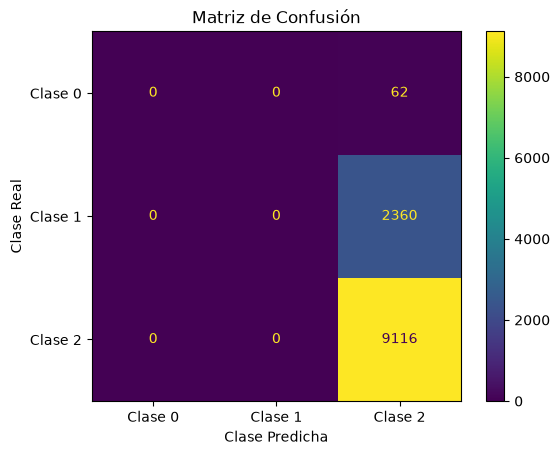

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones del modelo
y_pred = model.predict(x_test)

# Convertir probabilidades a la clase predicha
y_pred = y_pred.argmax(axis=1)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Clase 0", "Clase 1", "Clase 2"]
)

disp.plot()

plt.title("Matriz de Confusión")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.show()